In [1]:
import torch
import torch.nn as nn
import torch.optim as optim 
import torch.nn.functional as F
import torchvision
from torch.utils.data import DataLoader, Dataset
from torchvision.datasets import ImageFolder
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
import numpy as np
import tifffile

from pathlib import Path
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd

from typing import Optional, List, Callable

import os
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
class Road_Dataset(Dataset):
    def __init__(
            self,
            root: str,
            split: str,
            binarize_mask: bool = True,
            transforms: Optional[A.Compose] = None
    ):
        super().__init__()
        self.root = Path(root)
        self.split = split
        self.binarize_mask = binarize_mask
        self.transforms = transforms

        self.images_dir = self.root / split
        self.mask_dir = self.root / f"{split}_labels"

        images_paths = sorted(self.images_dir.glob("*.tiff"))
        self.images_paths = []
        self.mask_map = {}

        for img_path in images_paths:
            mask_path = self.mask_dir / f"{img_path.stem}.tif"
            if mask_path.exists():

                img = tifffile.imread(img_path)

                white_ratio = np.mean(np.all(img[..., :3] == 255, axis= -1))

                if white_ratio < 0.3: 
                    self.images_paths.append(img_path)
                    self.mask_map[img_path.stem] = mask_path
        print(f"Осталось: {len(self.images_paths)} из {len(images_paths)}\n")

    def __len__(self) -> int:
        return len(self.images_paths)
    
    def __getitem__(self, index : int):
        img_path = self.images_paths[index]
        mask_path = self.mask_map[img_path.stem]
        
        image = tifffile.imread(img_path)
        mask = tifffile.imread(mask_path)

        if self.binarize_mask:
            if mask.ndim == 3:
                mask = mask[..., 0]
            mask = (mask > 0).astype(np.float32)

        if self.transforms:
            augmented = self.transforms(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
            if mask.ndim == 2:
                mask = mask.unsqueeze(0)
        
        return image, mask

In [3]:
data_path = "archive/tiff"

train_transform = A.Compose([
    A.RandomCrop(height=512, width= 512),
    A.HorizontalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

train_dataset = Road_Dataset(root=data_path, split="train", transforms=train_transform)
val_dataset = Road_Dataset(root=data_path, split="val", transforms=val_transform)
test_dataset = Road_Dataset(root=data_path, split="test", transforms= val_transform)

print(f"train dataset len:{len(train_dataset)}")
print(f"val dataset len:{len(val_dataset)}")
print(f"test dataset len:{len(test_dataset)}")

train dataset len:1108
val dataset len:14
test dataset len:49


не использовать черные области с датасета

In [4]:
train_loader = DataLoader(train_dataset, batch_size= 8, shuffle= True, pin_memory= True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle= False, pin_memory= True)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle= False, pin_memory= True)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.3262744].


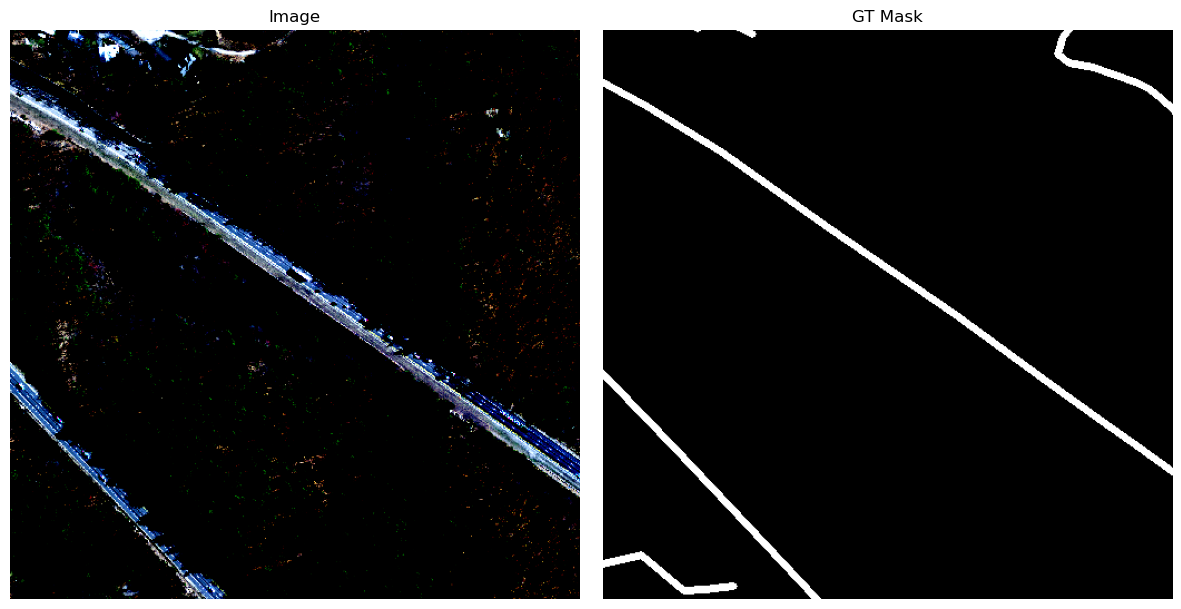

Image shape: torch.Size([3, 512, 512])
Mask shape: torch.Size([1, 512, 512])


In [5]:
images, masks = next(iter(train_loader))
image, mask = images[0], masks[0]


image_vis = image.permute(1, 2, 0).cpu().numpy()
mask_vis = mask.squeeze(0).cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(image_vis)
axes[0].set_title("Image")
axes[0].axis("off")

axes[1].imshow(mask_vis, cmap="gray")
axes[1].set_title("GT Mask")
axes[1].axis("off")

plt.tight_layout()
plt.show()

print("Image shape:", image.shape if hasattr(image, "shape") else type(image))
print("Mask shape:", mask.shape if hasattr(mask, "shape") else type(mask))

In [6]:
class DecoderBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()

        self.upconv = nn.ConvTranspose2d(
            in_channels, in_channels // 2, kernel_size=2, stride=2
        )

        conv_in_channels = (in_channels // 2) + skip_channels
        
        self.conv_block = nn.Sequential(
            nn.Conv2d(conv_in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x, skip=None):
        x = self.upconv(x)

        if skip is not None:
            x = torch.cat([skip, x], dim=1)
        x = self.conv_block(x)
        return x

class ResNet18_UNet_ConvTranspose(nn.Module):
    def __init__(self, num_classes=1):
        super().__init__()

        encoder = torchvision.models.resnet18(weights='IMAGENET1K_V1')
        
        self.enc1 = nn.Sequential(encoder.conv1, encoder.bn1, encoder.relu) # [64, H/2, W/2]
        self.enc2 = nn.Sequential(encoder.maxpool, encoder.layer1)          # [64, H/4, W/4]
        self.enc3 = encoder.layer2                                          # [128, H/8, W/8]
        self.enc4 = encoder.layer3                                          # [256, H/16, W/16]
        self.enc5 = encoder.layer4                                          # [512, H/32, W/32]
        
        self.dec5 = DecoderBlock(512, 256, 256)
        self.dec4 = DecoderBlock(256, 128, 128)
        self.dec3 = DecoderBlock(128, 64, 64)
        self.dec2 = DecoderBlock(64, 64, 64)
        
        self.dec1 = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
        )
        
        self.final_conv = nn.Conv2d(32, num_classes, kernel_size=1)

    def forward(self, x):
        f1 = self.enc1(x)
        f2 = self.enc2(f1)
        f3 = self.enc3(f2)
        f4 = self.enc4(f3)
        bottom = self.enc5(f4)
        
        d5 = self.dec5(bottom, f4)
        d4 = self.dec4(d5, f3)
        d3 = self.dec3(d4, f2)
        d2 = self.dec2(d3, f1)
        d1 = self.dec1(d2)
    
        out = self.final_conv(d1)
        return out

In [ ]:
model = ResNet18_UNet_ConvTranspose(num_classes=1).to(device)

criterion = smp.losses.DiceLoss(mode='binary')
optimizer = optim.AdamW(model.parameters(), lr=0.0001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor= 0.1, patience= 3)
SAVE_DIR = "checkpoints"
EPOCH_SAVE_DIR = "running_results"
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(EPOCH_SAVE_DIR, exist_ok= True)

In [8]:
def get_metrics(outputs, masks, threshold = 0.5):
    probs = torch.sigmoid(outputs)
    preds = (probs > threshold).float()

    preds = preds.view(-1)
    masks = masks.view(-1)

    intersection = (preds * masks).sum()
    total = preds.sum() + masks.sum()
    union = total - intersection

    smooth = 1e-6

    IoU = (intersection + smooth) / (union + smooth)

    f1 = (2. * intersection + smooth) / (total + smooth)
    
    return IoU.item(), f1.item()

In [9]:
def sliding_window(model, image, patch_size = 512, stride = 256):
    B, C, H, W = image.shape

    preds = torch.zeros((B, 1, H, W), device= image.device)
    counts = torch.zeros((B, 1, H, W), device= image.device)

    for y in range(0, H, stride):
        for x in range(0, W, stride):
            x1 = min(x, max(0, W - patch_size))
            y1 = min(y, max(0, H - patch_size))
            x2 = min(x1 + patch_size, W)
            y2 = min(y1 + patch_size, H)

            patch = image[:, :, y1:y2, x1:x2]

            pad_h = patch_size - patch.shape[2]
            pad_w = patch_size - patch.shape[3]

            if pad_h > 0 or pad_w > 0:
                patch = F.pad(patch, (0, pad_w, 0, pad_h))

            logits = model(patch)
            
            if pad_h > 0 or pad_w > 0:
                logits = logits[:, :, :patch.shape[2], :patch.shape[3]]

            preds [:, :, y1:y2, x1:x2] += logits
            counts [:, :, y1:y2, x1:x2] += 1

    output = preds / torch.clamp(counts, min=1)
    return output

def train_epoch(model, loader, optimizer, criterion, device = device):
    model.train()
    running_loss = 0.0

    pbar = tqdm(loader, desc= "Training")
    for images, masks in pbar:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, masks)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        pbar.set_postfix({"loss":loss.item()})
    
    return running_loss / len(loader)

@torch.no_grad()
def validate(model, loader, criterion, device = device):
    model.eval()
    running_loss = 0.0 
    running_iou = 0.0
    running_f1 = 0.0

    pbar = tqdm(loader, desc= "Validation", leave=False)
    for images, masks in pbar:
        images = images.to(device)
        masks = masks.to(device)

        logits = sliding_window(model, images, patch_size=  512, stride= 256)
        loss = criterion(logits, masks)

        running_loss += loss.item()

        iou, f1 = get_metrics(logits, masks)

        running_iou += iou
        running_f1 += f1
    
    
    return running_loss / len(loader), running_iou / len(loader), running_f1 / len(loader)

In [ ]:
EPOCHS = 67
best_iou = 0.0
checkpoint_every = 3

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    train_loss = train_epoch(model, train_loader, optimizer, criterion)

    val_loss, val_iou, val_f1 = validate(model, val_loader, criterion)

    print(f"Train loss: {train_loss:.4f} | Val_loss: {val_loss:.4f}\n")
    print(f"Val IoU: {val_iou:.4f} | Val F1: {val_f1:.4f}")

    scheduler.step(val_iou)

    if val_iou > best_iou: 
        best_iou = val_iou
        torch.save(model.state_dict(), f"{SAVE_DIR}/best_unet_IoU_{best_iou}.pth")
        print(">>> Best model saved! <<<")

    if (epoch + 1) % checkpoint_every == 0:
        checkpoint = {
            'epoch' : epoch,
            'model_state_dict' : model.state_dict(),
            'optimizer_state_dict' : optimizer.state_dict(),
            'scheduler_state_dict' : scheduler.state_dict(),
            'val_IoU' : val_iou
        }
        torch.save(checkpoint, f"{EPOCH_SAVE_DIR}/checkpoint_{epoch+1}.pth")


Epoch 1/50


Training: 100%|██████████| 139/139 [00:43<00:00,  3.21it/s, loss=0.911]


Train loss: 0.8433 | Val_loss: 0.7332

Val IoU: 0.3710 | Val F1: 0.5411
>>> Best model saved! <<<

Epoch 2/50


Training: 100%|██████████| 139/139 [00:36<00:00,  3.80it/s, loss=0.813]


Train loss: 0.8053 | Val_loss: 0.6960

Val IoU: 0.4290 | Val F1: 0.6004
>>> Best model saved! <<<

Epoch 3/50


...

Train loss: 0.3049 | Val_loss: 0.2408

Val IoU: 0.6217 | Val F1: 0.7664

Epoch 49/50


Training: 100%|██████████| 139/139 [00:36<00:00,  3.83it/s, loss=0.413]


Train loss: 0.2941 | Val_loss: 0.2397

Val IoU: 0.6231 | Val F1: 0.7675
>>> Best model saved! <<<

Epoch 50/50


Training: 100%|██████████| 139/139 [00:36<00:00,  3.80it/s, loss=0.189]
                                                         

Train loss: 0.3004 | Val_loss: 0.2411

Val IoU: 0.6212 | Val F1: 0.7660


доучить модель + домен поправить
сохранять сиды торча и лоадеров

Веса загружены из файла: checkpoints/best_unet_IoU_0.6231106817722321.pth


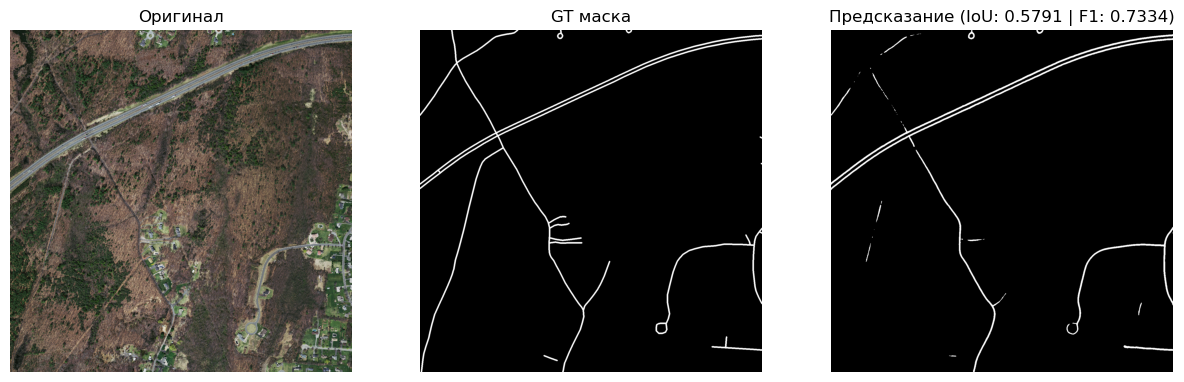

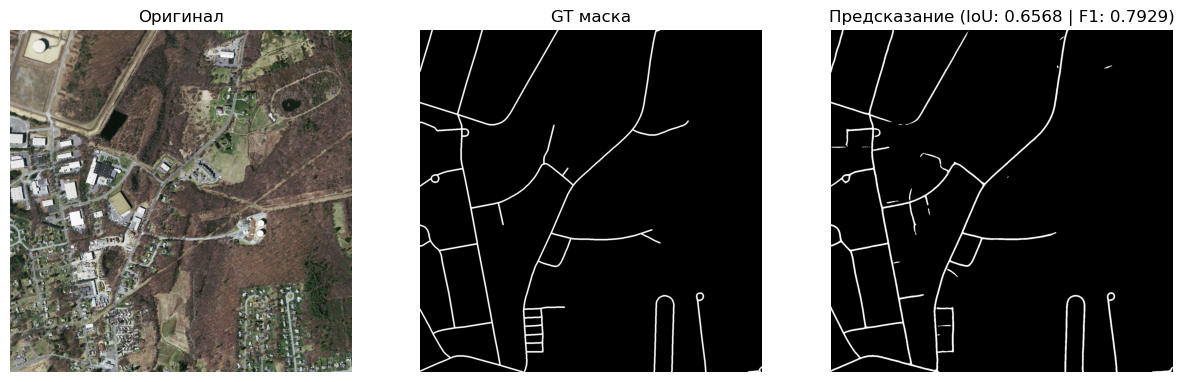

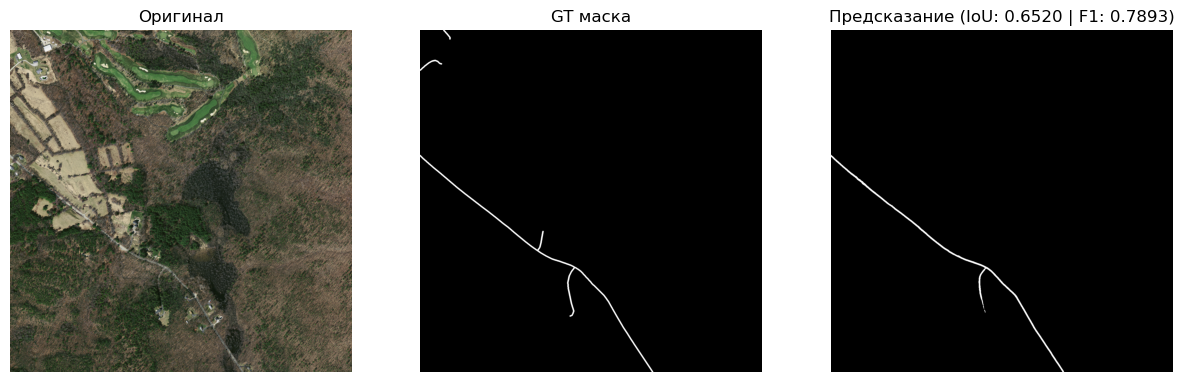

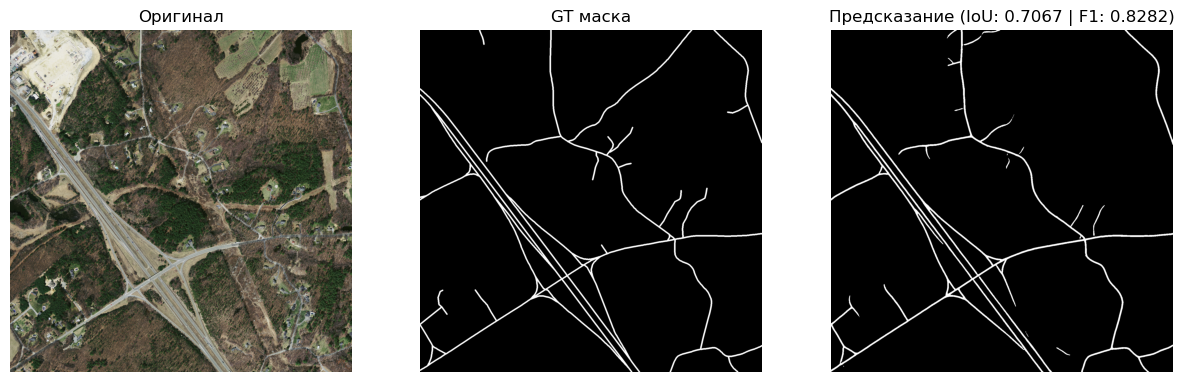

------------------------------
Avg IoU Score на тесте: 0.6451
Avg F1 (Dice) Score на тесте: 0.7835


In [10]:
import os
import glob
import matplotlib.pyplot as plt
import torch
import numpy as np

model_paths = glob.glob("checkpoints/best_unet_IoU_*.pth")
if model_paths:

    best_model_path = max(model_paths, key=os.path.getmtime)
    model.load_state_dict(torch.load(best_model_path, map_location=device))
    print(f"Веса загружены из файла: {best_model_path}")
else:
    print("Сохраненные веса не найдены! Используются текущие веса модели.")

model.eval()
test_f1 = 0.0
test_iou = 0.0
num_samples = 0

patch_size = 512
stride = 256

with torch.no_grad():
    for i, (images, masks) in enumerate(test_loader):
        images = images.to(device)
        masks = masks.to(device)

        logits = sliding_window(model, images, patch_size=patch_size, stride=stride)
        
        iou, f1 = get_metrics(logits, masks)
        
        test_iou += iou
        test_f1 += f1
        num_samples += 1

        if i in range(0, 4):
            
            img_vis = images[0].permute(1, 2, 0).cpu().numpy()
            mean = np.array([0.485, 0.456, 0.406])
            std = np.array([0.229, 0.224, 0.225])
            img_vis = std * img_vis + mean
            img_vis = np.clip(img_vis, 0, 1)

            gt_vis = masks[0].squeeze().cpu().numpy()

            probs = torch.sigmoid(logits[0])
            pred_vis = (probs.squeeze() > 0.5).cpu().numpy()
            
            fig, axes = plt.subplots(1, 3, figsize=(15, 5))
            axes[0].imshow(img_vis)
            axes[0].set_title("Оригинал")
            axes[0].axis("off")

            axes[1].imshow(gt_vis, cmap="gray")
            axes[1].set_title("GT маска")
            axes[1].axis("off")

            axes[2].imshow(pred_vis, cmap="gray")
            axes[2].set_title(f"Предсказание (IoU: {iou:.4f} | F1: {f1:.4f})")
            axes[2].axis("off")
            plt.show()

avg_test_iou = test_iou / max(1, num_samples)
avg_test_f1 = test_f1 / max(1, num_samples)

print('-'*30)
print(f'Avg IoU Score на тесте: {avg_test_iou:.4f}')
print(f'Avg F1 (Dice) Score на тесте: {avg_test_f1:.4f}')

In [ ]:
# from torchview import draw_graph
# import graphviz



# model_graph = draw_graph(
#     model, 
#     input_size=(1, 3, 512, 512), 
#     expand_nested=True, 
#     depth=3, 
#     device=device,
#     save_graph=True,
#     filename="unet_architecture",
#     directory="./"
# )


# print(f"Граф сохранен как unet_architecture.png.pdf")
# model_graph.visual_graph

In [ ]:

def print_gpu_memory():
    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated() / 1024**2
        reserved = torch.cuda.memory_reserved() / 1024**2
        print(f"--- GPU Memory Info ---")
        print(f"Allocated: {allocated:.2f} MiB") 
        print(f"Reserved:  {reserved:.2f} MiB")  
        print(f"-----------------------")
    else:
        print("CUDA не доступна.")

print_gpu_memory()


try:
    from torchinfo import summary
    model_stats = summary(model, input_size=(8, 3, 512, 512), device=device)
    print(model_stats)
except ImportError:
    print("\nДля детальной таблицы установите: !pip install torchinfo")